## **Tutorial 1. PLS Regression Model for Reaction Monitoring**
### **Tutorial 1.2. Exploratory Data Analysis**
In this notebook we explore the calibration data assembled in Tutorial 1.1. We start by visualising the raw spectra, then use PCA to understand the structure of the data — first on the raw spectra and then after applying a preprocessing pipeline.

In [78]:
# Standard data science imports
import pandas as pd
import numpy as np


#### **A. Load the data**
We load the calibration DataFrame saved in Tutorial 1.1. The spectra (`y`) and the wavenumber axis (`x`) are extracted as NumPy arrays.

In [79]:
path_to_data = r"local/tutorial_1_calibration_data.parquet"

# Load the calibration DataFrame assembled in Tutorial 1.1
df = pd.read_parquet(path_to_data)

# Extract the spectral matrix (rows = samples, columns = wavenumber points)
X = np.array(df["y"].to_list())
x_axis = np.array(df["x"].to_list()[0])  # x-axis is the same for all spectra


#### **B. Visualise the raw spectra**
We start with a simple overlay of all calibration spectra, then colour them by the known concentrations of A and B. Colouring by concentration is a quick way to check whether the spectral variation tracks the chemistry we want to model.

**See also:** [Plotting fundamentals](https://chemotools.org/explore/plotting_fundamentals.html)

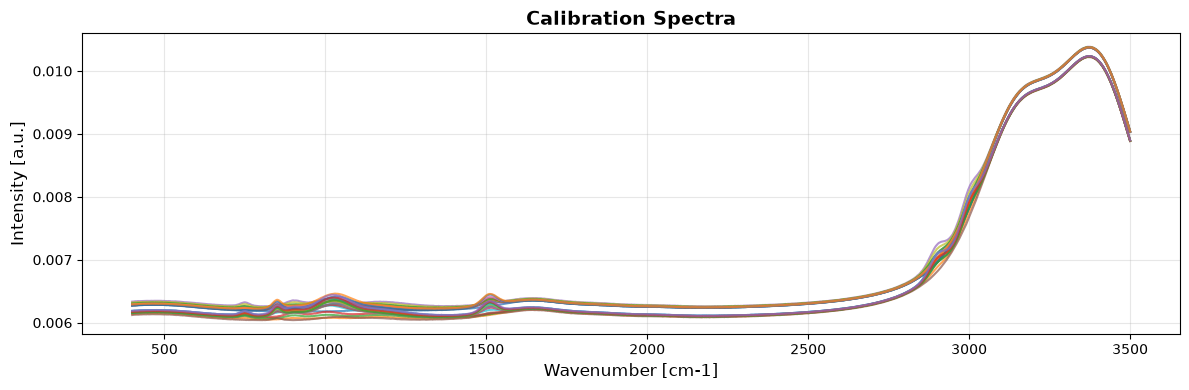

In [80]:
from chemotools.plotting import SpectraPlot

# Plot all calibration spectra overlaid
SpectraPlot(
    x=x_axis,
    y=X,
).show(
    title="Calibration Spectra", xlabel="Wavenumber [cm-1]", ylabel="Intensity [a.u.]"
);


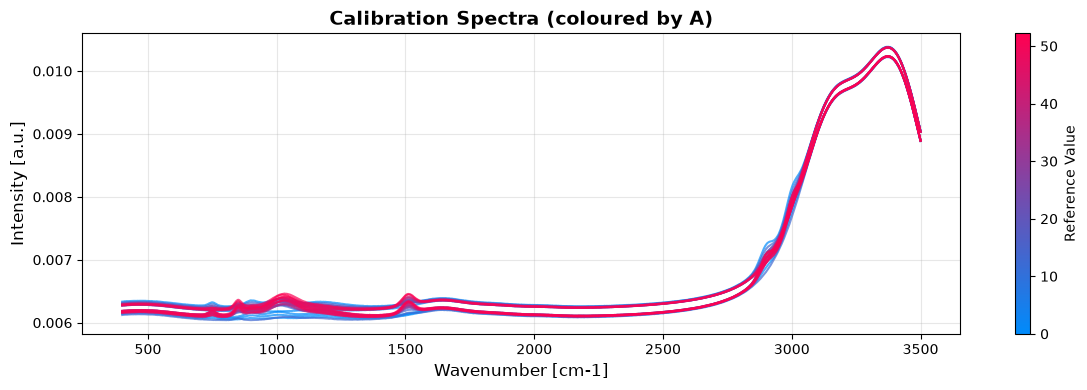

In [81]:
# Colour the spectra by concentration of A to check for spectral trends
color_by = df["A"].to_numpy()
SpectraPlot(
    x=x_axis,
    y=X,
    color_by=color_by,
).show(
    title="Calibration Spectra (coloured by A)",
    xlabel="Wavenumber [cm-1]",
    ylabel="Intensity [a.u.]",
);


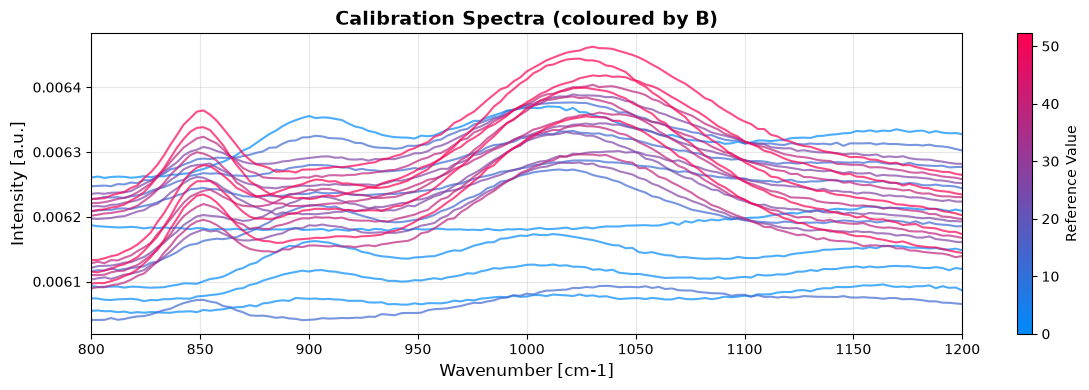

In [82]:
# Colour by concentration of B and zoom into the most informative spectral region
color_by = df["A"].to_numpy()
SpectraPlot(
    x=x_axis,
    y=X,
    color_by=color_by,
).show(
    title="Calibration Spectra (coloured by B)",
    xlabel="Wavenumber [cm-1]",
    ylabel="Intensity [a.u.]",
    xlim=(800, 1200),
);


#### **C. PCA without preprocessing**
We apply PCA directly to the mean-centred raw spectra as a baseline. This lets us see how much structure is already present in the data before any preprocessing is applied.

**See also:** [Inspecting your models](https://chemotools.org/explore/inspector_fundamentals.html)

In [83]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Mean-centre the data and fit a 2-component PCA
pipe = make_pipeline(StandardScaler(with_std=False), PCA(n_components=2))
pipe.fit(X)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('pca', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1024
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](1024,)","[0.01,0.01,0.01,...,0.01,0.01,0.01]"


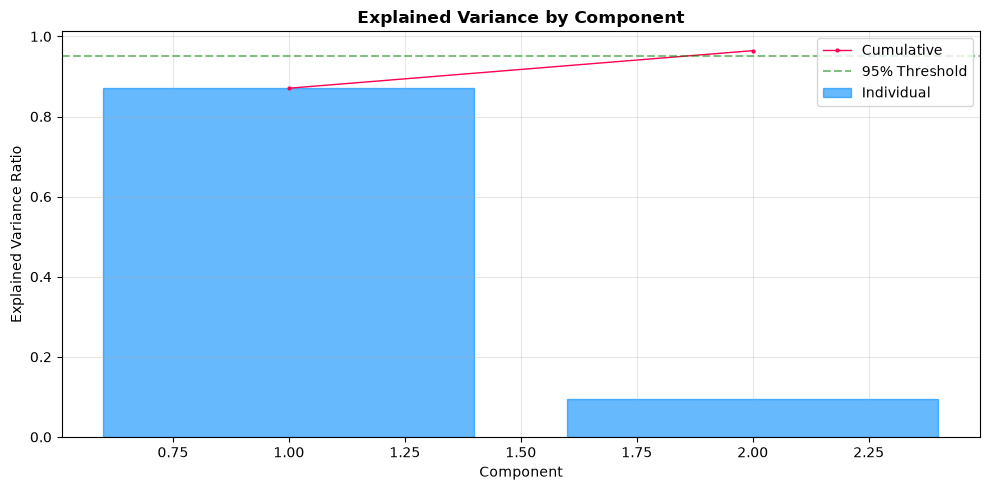

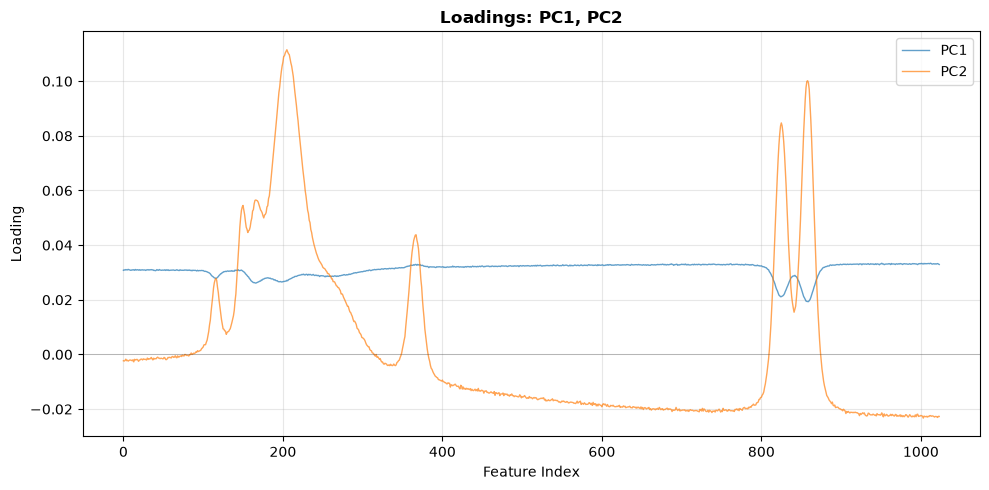

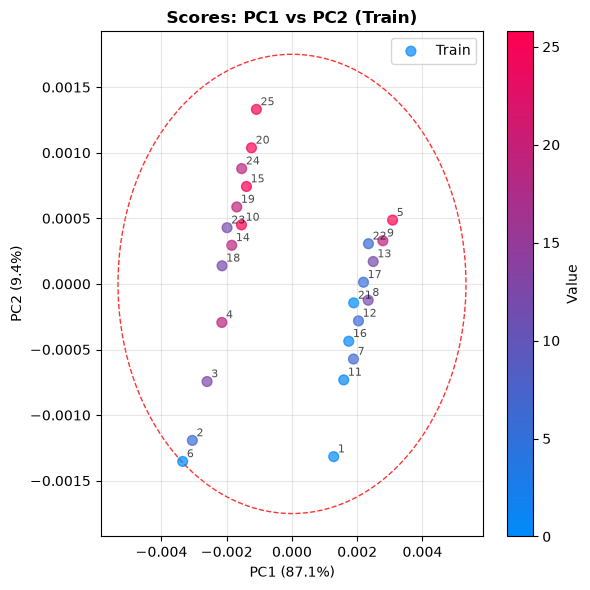

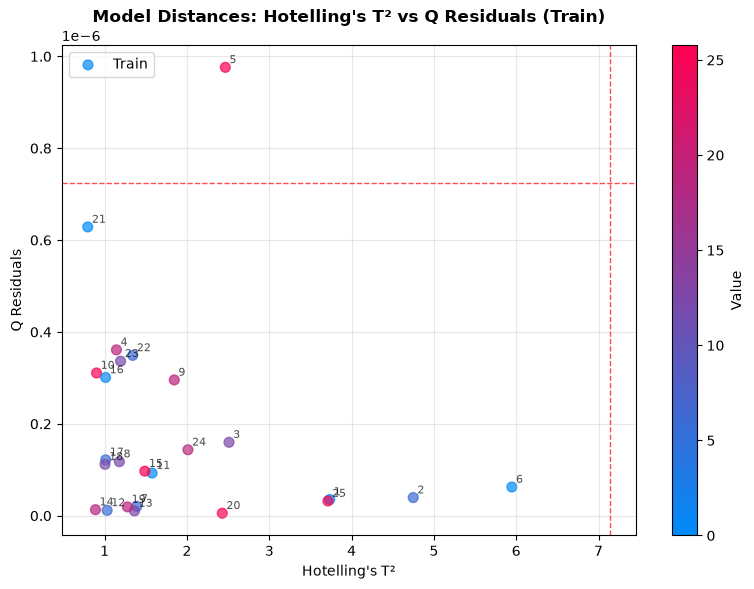

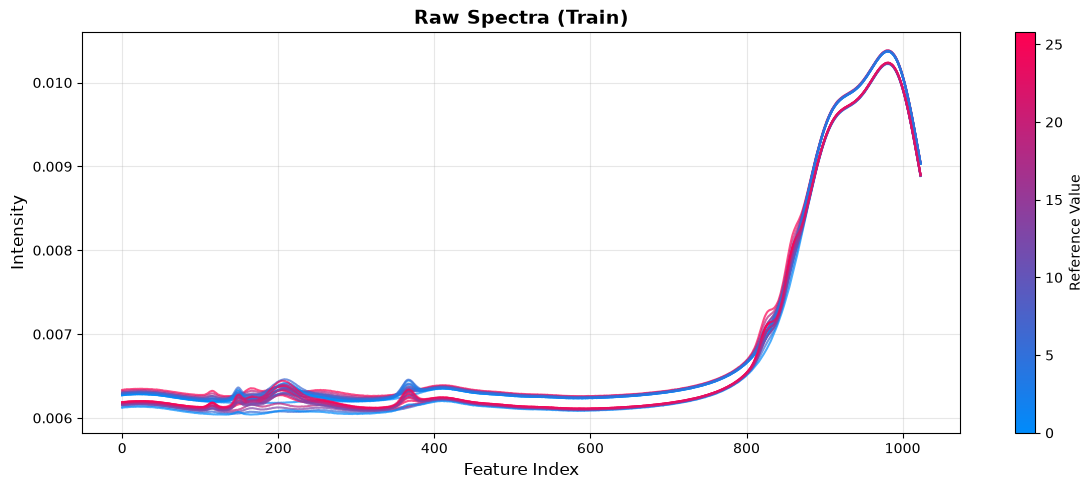

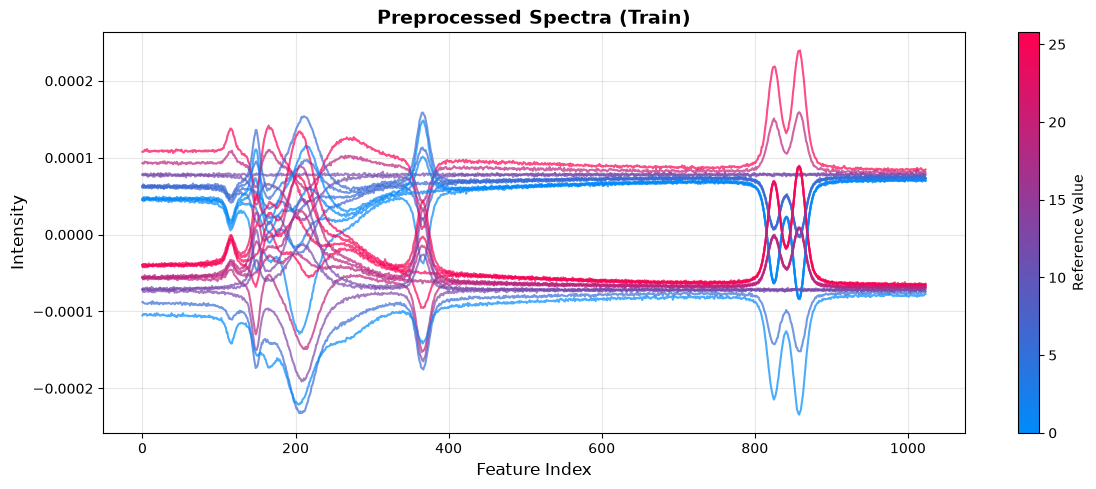

In [84]:
from chemotools.inspector import PCAInspector

# Visualise the PCA scores, coloured by concentration of B and annotated by sample number
color_by = df["B"].to_numpy()
PCAInspector(pipe, X_train=X, y_train=color_by).inspect(annotate_by=df["sample_nr"]);


The scores plot shows two distinct blocks of samples, which is unexpected for a continuous calibration set. Before assuming this reflects chemistry, we should check whether the separation is caused by an external factor. We will colour the scores by different criteria to investigate — starting with the measurement date and time.

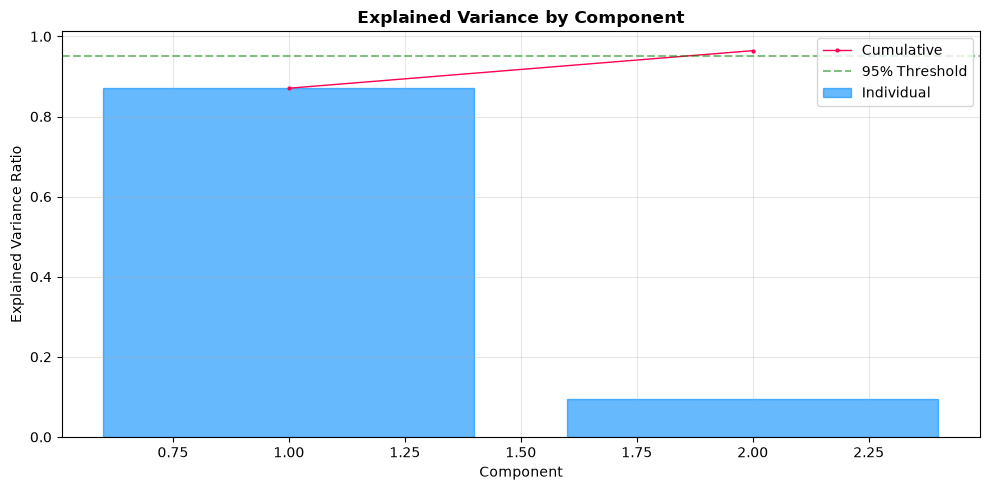

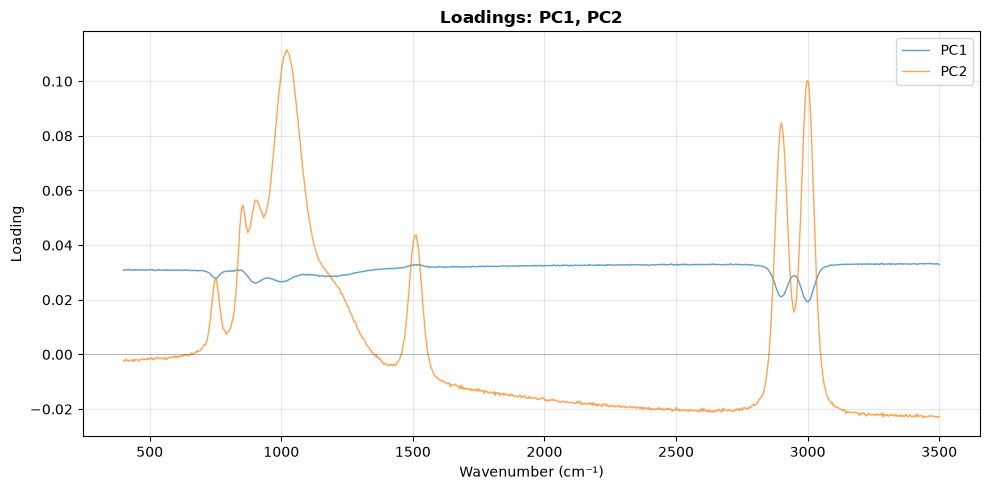

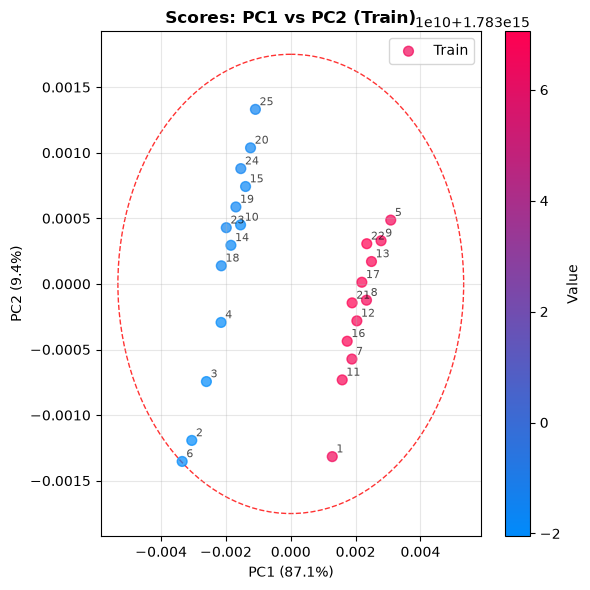

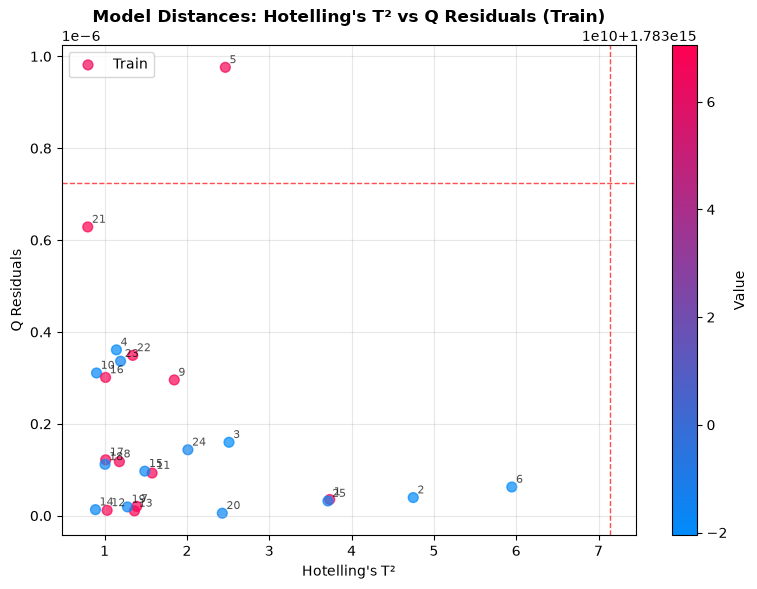

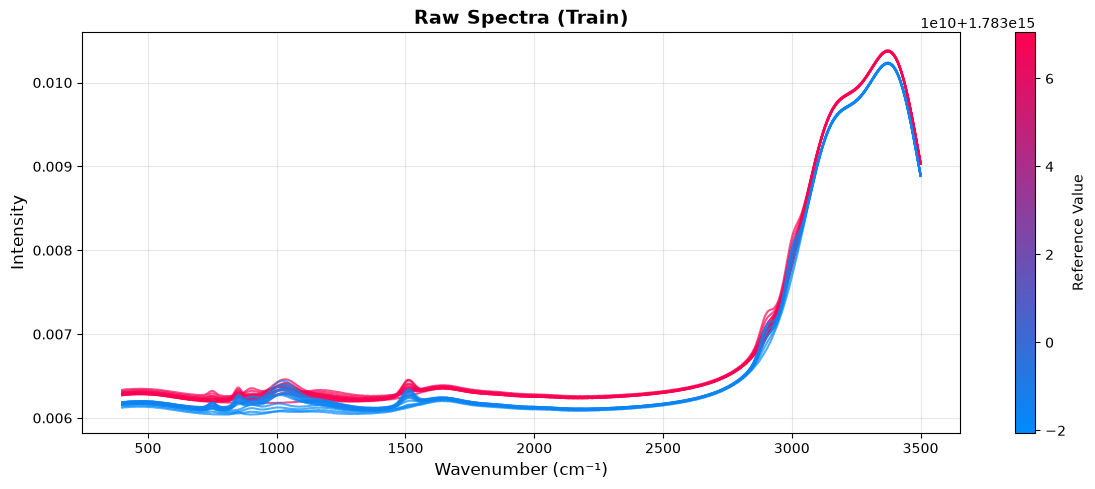

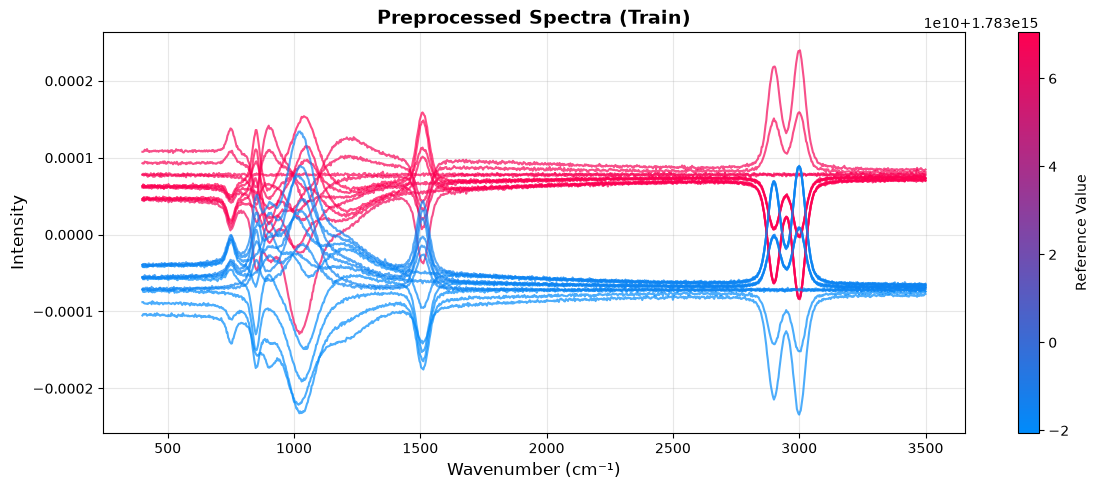

In [85]:
# Color by datetime
color_by = df["datetime"].to_numpy().astype(float)
PCAInspector(pipe, X_train=X, y_train=color_by, x_axis=x_axis).inspect(
    annotate_by=df["sample_nr"]
);


#### **D. PCA with preprocessing**
Raw Raman spectra often contain baseline offsets and laser intensity deviationsthat obscure chemical information. Here we add a MinMax normalisation and a first-derivative Savitzky–Golay filter before PCA to reduce these artefacts.

**See also:** [MinMaxScaler](https://chemotools.org/api/scale.html) · [SavitzkyGolay](https://chemotools.org/api/derivative.html) · [Creating pipelines](https://chemotools.org/explore/pipelines.html) · [Inspecting your models](https://chemotools.org/explore/inspector_fundamentals.html)

In [86]:
from chemotools.scale import MinMaxScaler
from chemotools.derivative import SavitzkyGolay
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Build a pipeline: normalise → first derivative (SG) → mean-centre → PCA
pipe = make_pipeline(
    MinMaxScaler(),
    SavitzkyGolay(window_length=11, polyorder=2, deriv=1),
    StandardScaler(with_std=False),
    PCA(n_components=2),
)
pipe.fit(X)


Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('savitzkygolay', SavitzkyGolay(polyorder=2, window_length=11)),
                ('standardscaler', StandardScaler(with_std=False)),
                ('pca', PCA(n_components=2))])

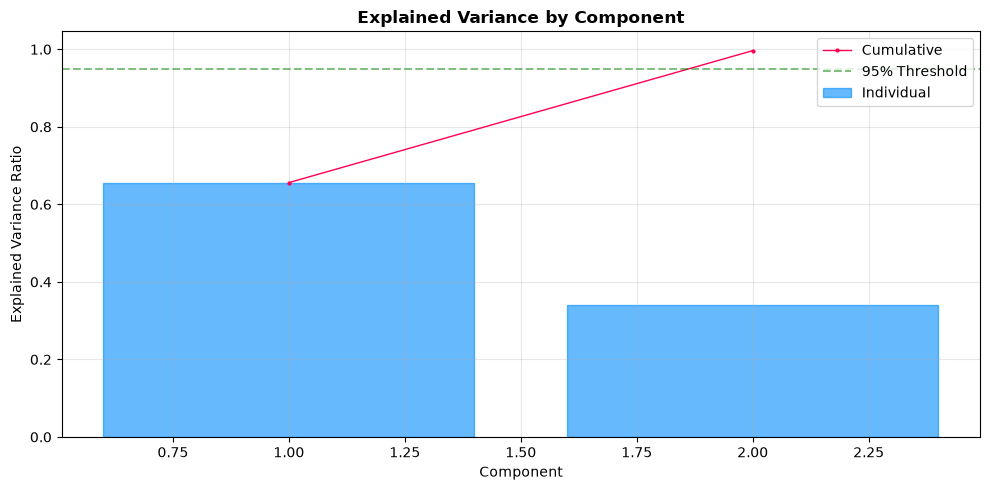

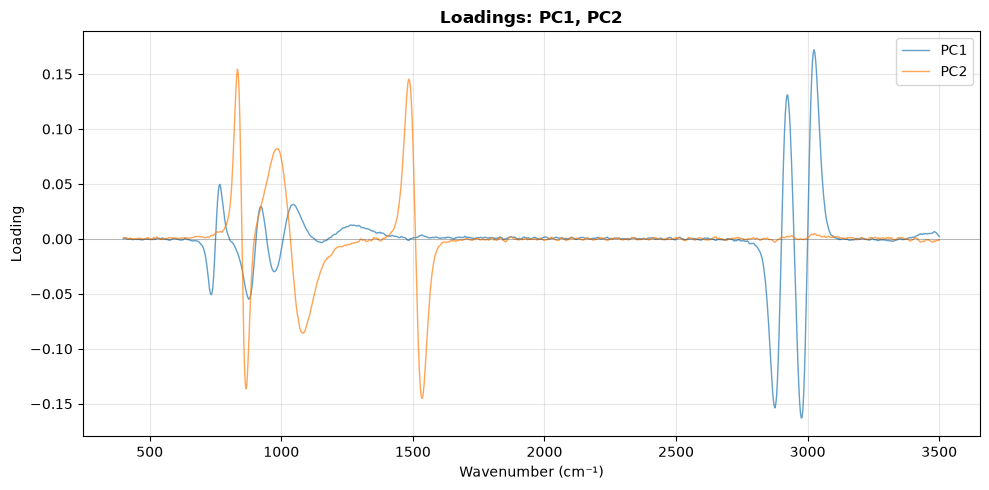

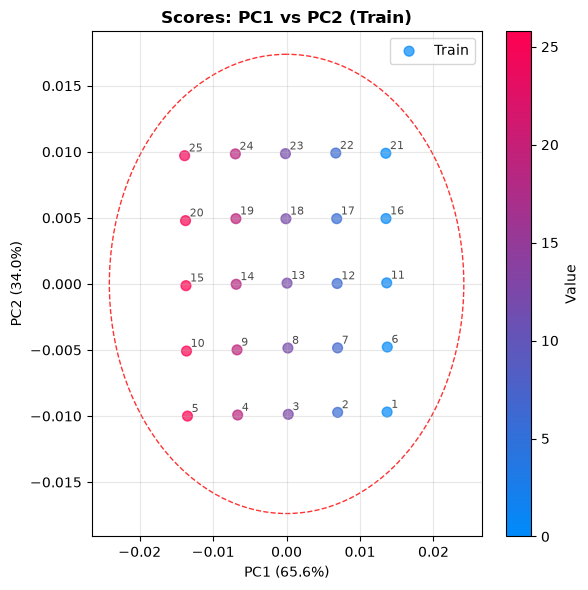

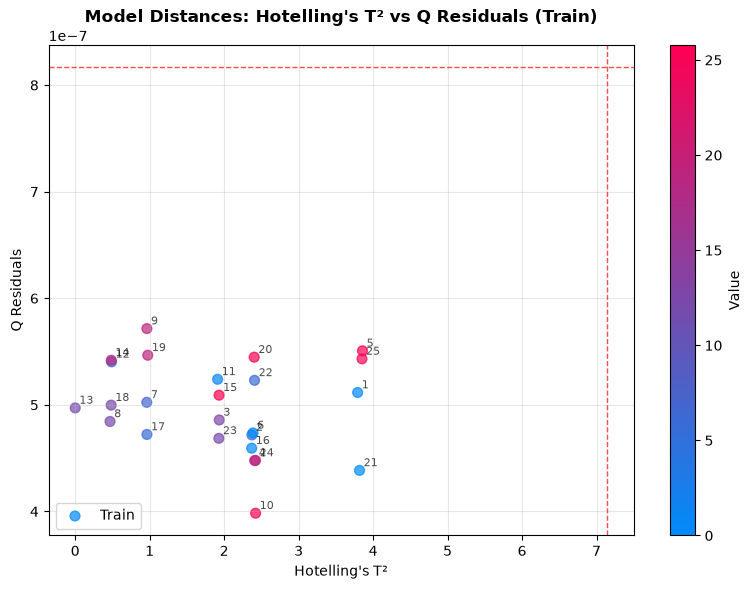

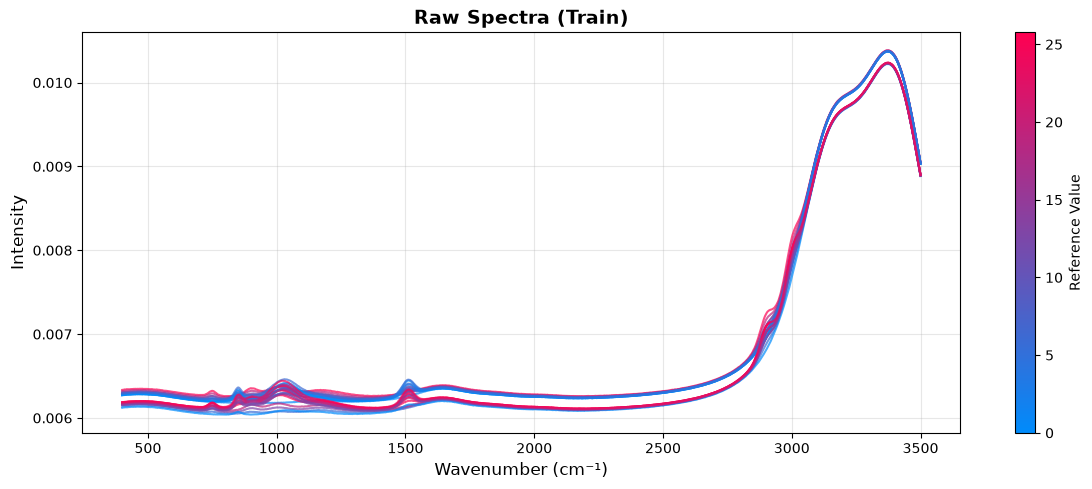

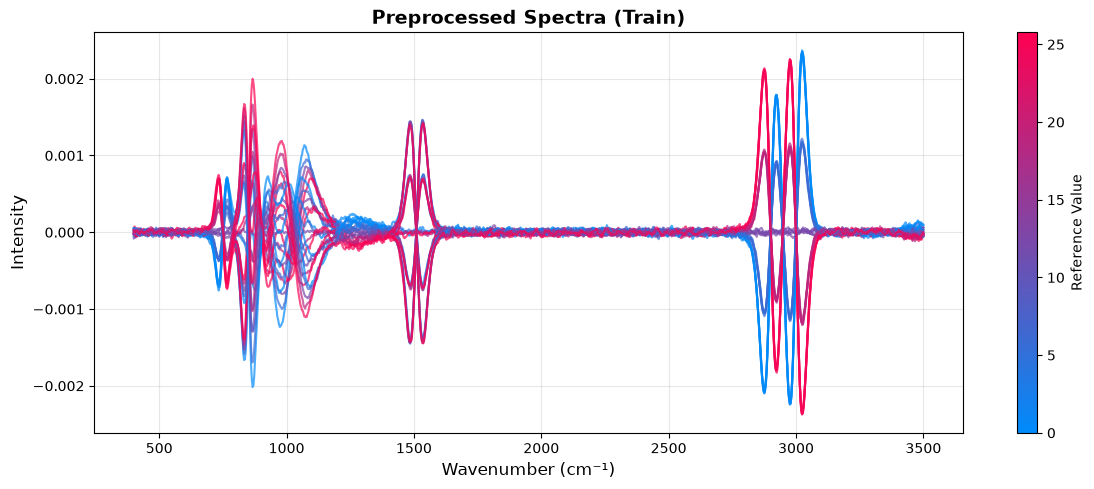

In [87]:
from chemotools.inspector import PCAInspector

# Inspect the preprocessed PCA scores — separation should be cleaner than without preprocessing
color_by = df["B"].to_numpy()
PCAInspector(pipe, X_train=X, y_train=color_by, x_axis=x_axis).inspect(
    annotate_by=df["sample_nr"]
);
